In [43]:
import numpy as np
import pandas as pd

#pd.set_option("display.max_columns", None)
#df = pd.read_parquet("s3://tradebot-config-tokyo/data/trade/APTUSDT/2024-01.parquet")
#df = pd.read_parquet("s3://tradebot-config-tokyo/data/book/APTUSDT/2024-01.parquet")
#df = pd.read_parquet("s3://tradebot-config-tokyo/data/bougie/BTCUSDT/BTCUSDT-1m-2024.parquet")
df = pd.read_parquet("s3://tradebot-config-tokyo/data/v1/wf_stage0_tagged_2024-04.parquet")
#df = pd.read_parquet("s3://tradebot-config-tokyo/data/v1_evalready/wf_stage0_evalready_2025-05.parquet")
print(list(df.columns))
print(df.head(3))

['timestamp', 'bid_0_price', 'ask_0_price', 'bid_0_size', 'ask_0_size', 'bid_1_size', 'ask_1_size', 'bid_2_size', 'ask_2_size', 'bid_3_size', 'ask_3_size', 'bid_4_size', 'ask_4_size', 'bid_5_size', 'ask_5_size', 'bid_6_size', 'ask_6_size', 'bid_7_size', 'ask_7_size', 'bid_8_size', 'ask_8_size', 'bid_9_size', 'ask_9_size', 'bid_10_size', 'ask_10_size', 'bid_11_size', 'ask_11_size', 'bid_12_size', 'ask_12_size', 'bid_13_size', 'ask_13_size', 'bid_14_size', 'ask_14_size', 'bid_15_size', 'ask_15_size', 'notional_buy', 'notional_sell', 'qty_buy', 'qty_sell', 'ntr', 'Nb', 'Ns', 'Ntot', 'TI', 'nps', 'notional_ps_dbg', 'mid', 'spread_bps', 'micro', 'micro_bias_bps', 'Dbid_1', 'Dask_1', 'OBI_1', 'Dbid_3', 'Dask_3', 'OBI_3', 'Dbid_5', 'Dask_5', 'OBI_5', 'Dbid_10', 'Dask_10', 'OBI_10', 'Dbid_14', 'Dask_14', 'OBI_14', 'spread_ticks', 'spread_ticks_1s', 'spread_ticks_med_5m', 'spread_rel_5m', 'range_60s_bps', 'range_10m_bps', 'dir0', 'persist_micro_ms', 'persist_obi10_ms', 'Dopp_3', 'Dopp_10', 'thi

In [ ]:
import pandas as pd
from ml_bot.backtest.lib.io_s3 import read_parquet_s3

DATASET = "s3://tradebot-config-tokyo/research/ms_edge/ml/stageb_dataset.parquet"

df = read_parquet_s3(DATASET)
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

df = df[(df["is_tradeable_baseline"] == 1) & (df["router_branch"] == "BO")].copy()

def map_regime3(v):
    if v in ("b0", "b1"):
        return "low"
    if v == "b2":
        return "mid"
    if v in ("b3", "b4"):
        return "high"
    return "other"

df["vol_regime3"] = df["vol_bucket"].map(map_regime3)

print(df.groupby(["split", "vol_regime3"]).size())
print("\ny_go by split/regime:")
print(df.groupby(["split", "vol_regime3"])["y_go"].mean())

rows: 398

=== EV BY SCORE DECILE (TEST) ===

   decile   n     ev_bps   pnl_p50    pnl_p95  score_min  score_max
0       0  40  12.016614  8.853242  46.615986   0.844371   0.871595
1       1  40   6.650420  7.909974  39.646370   0.832770   0.844128
2       2  40   2.820666 -0.300833  25.364096   0.824110   0.832770
3       3  39   5.705145  4.635414  25.796850   0.815107   0.824110
4       4  40   3.099616  1.739706  24.643325   0.805157   0.815024
5       5  40   3.373239  2.846957  25.736768   0.790991   0.804663
6       6  39   4.170521  4.848169  26.129158   0.761585   0.789880
7       7  40   8.281950  6.471996  26.824379   0.734245   0.761397
8       8  40   4.786440  3.631130  25.179527   0.681897   0.734241
9       9  40   5.022101  6.541702  20.878826   0.489928   0.679277


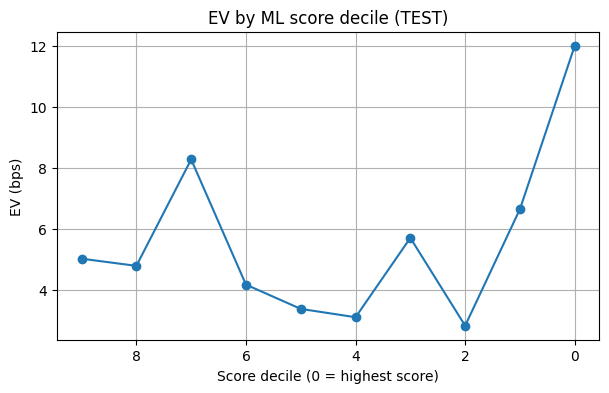

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ml_bot.backtest.lib.io_s3 import read_parquet_s3

# =========================================================
# LOAD TEST SCORES (HIGH REGIME MODEL)
# =========================================================

RUN_ID = "stageb_ml_high_f679fa8b18"
RUN_ROOT = f"s3://tradebot-config-tokyo/research/ms_edge/ml/runs/run_id={RUN_ID}"

df = read_parquet_s3(f"{RUN_ROOT}/scored_test.parquet")

df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

print("rows:", len(df))

# =========================================================
# CREATE DECILES
# =========================================================

df = df.dropna(subset=["score", "pnl_net_bps"]).copy()

df["decile"] = pd.qcut(
    df["score"].rank(method="first"),
    10,
    labels=False
)

# highest score = decile 0
df["decile"] = 9 - df["decile"]

# =========================================================
# EV PER DECILE
# =========================================================

ev_table = (
    df.groupby("decile")
    .agg(
        n=("pnl_net_bps", "count"),
        ev_bps=("pnl_net_bps", "mean"),
        pnl_p50=("pnl_net_bps", "median"),
        pnl_p95=("pnl_net_bps", lambda x: np.quantile(x, 0.95)),
        score_min=("score", "min"),
        score_max=("score", "max"),
    )
    .reset_index()
    .sort_values("decile")
)

print("\n=== EV BY SCORE DECILE (TEST) ===\n")
print(ev_table)

# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(7,4))
plt.plot(ev_table["decile"], ev_table["ev_bps"], marker="o")
plt.gca().invert_xaxis()

plt.xlabel("Score decile (0 = highest score)")
plt.ylabel("EV (bps)")
plt.title("EV by ML score decile (TEST)")

plt.grid(True)
plt.show()

In [40]:
import pandas as pd
import numpy as np

from ml_bot.backtest.lib.io_s3 import read_parquet_s3

RUN_ID = "stageb_ml_high_f679fa8b18"
RUN_ROOT = f"s3://tradebot-config-tokyo/research/ms_edge/ml/runs/run_id={RUN_ID}"

df = read_parquet_s3(f"{RUN_ROOT}/scored_test.parquet")

df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

print("rows:", len(df))

# =========================================================
# BASELINE
# =========================================================

baseline_ev = df["pnl_net_bps"].mean()

# =========================================================
# SIZE FUNCTION
# =========================================================

def size_from_score(s):

    if s > 0.84:
        return 1.5
    elif s > 0.82:
        return 1.2
    elif s > 0.78:
        return 1.0
    elif s > 0.72:
        return 0.7
    else:
        return 0.5


df["size"] = df["score"].apply(size_from_score)

# =========================================================
# SIZED PNL
# =========================================================

df["pnl_sized"] = df["pnl_net_bps"] * df["size"]

sized_ev = df["pnl_sized"].mean()

print("\n=== POSITION SIZING TEST ===\n")

print("baseline EV:", baseline_ev)
print("sized EV:", sized_ev)
print("improvement:", sized_ev - baseline_ev)

# =========================================================
# DISTRIBUTION
# =========================================================

print("\nsize distribution:")
print(df["size"].value_counts().sort_index())

rows: 398

=== POSITION SIZING TEST ===

baseline EV: 5.5959618481386215
sized EV: 5.654840204093804
improvement: 0.05887835595518265

size distribution:
size
0.5     69
0.7     80
1.0    103
1.2    100
1.5     46
Name: count, dtype: int64


In [41]:
import pandas as pd
import numpy as np

from ml_bot.backtest.lib.io_s3 import read_parquet_s3

RUN_ID = "stageb_ml_high_f679fa8b18"
RUN_ROOT = f"s3://tradebot-config-tokyo/research/ms_edge/ml/runs/run_id={RUN_ID}"

df = read_parquet_s3(f"{RUN_ROOT}/scored_test.parquet")

df = df.dropna(subset=["score","pnl_net_bps"]).copy()

print("rows:", len(df))

df = df.sort_values("score", ascending=False)

fractions = [0.05,0.10,0.20,0.30,0.40,0.50,1.0]

rows = []

for f in fractions:

    k = int(len(df)*f)

    sub = df.iloc[:k]

    rows.append({
        "fraction": f,
        "n_trades": k,
        "EV_bps": sub["pnl_net_bps"].mean(),
        "median_bps": sub["pnl_net_bps"].median(),
        "p95_bps": np.quantile(sub["pnl_net_bps"],0.95)
    })

res = pd.DataFrame(rows)

print("\n=== EDGE CONCENTRATION TEST ===\n")
print(res)

rows: 398

=== EDGE CONCENTRATION TEST ===

   fraction  n_trades     EV_bps  median_bps    p95_bps
0      0.05        19  15.085996   12.989198  38.687733
1      0.10        39  12.467437    9.583634  47.534506
2      0.20        79   9.502560    8.122849  44.687082
3      0.30       119   7.305845    5.561138  38.118827
4      0.40       159   6.805086    5.146274  37.087636
5      0.50       199   6.060268    4.553022  33.051828
6      1.00       398   5.595962    4.576919  29.934013
